In [1]:
!pip install -q transformers datasets evaluate accelerate peft bitsandbytes trl torch scikit-learn matplotlib pandas bert-score kernels

import os
import json
import random
import numpy as np
import torch
import transformers
from datetime import datetime

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA: {torch.version.cuda}")
print(f"PyTorch: {torch.__version__}")
print(f"Transformers: {transformers.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 3.6 MB/s eta 0:00:00
Device: cpu
PyTorch: 2.10.0+cpu
Transformers: 5.0.0


In [2]:
# ============================================================
# 2. CONFIG – THIS IS WHERE YOU CHANGE THINGS
# ============================================================
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
FALLBACK_MODEL = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
DATASET_NAME = "knkarthick/samsum"

OUTPUT_DIR = "./output_summarization"
ADAPTER_DIR = os.path.join(OUTPUT_DIR, "peft_adapter")
DPO_DIR = os.path.join(OUTPUT_DIR, "dpo_optimized")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Mode: True = 12-sample sanity run, False = full 12k+ training
SANITY_RUN = False

if SANITY_RUN:
    TRAIN_SAMPLES = 12
    EVAL_SAMPLES = 64
else:
    TRAIN_SAMPLES = 12000
    EVAL_SAMPLES = 512

# Training hyperparams
PER_DEVICE_TRAIN_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 16
NUM_TRAIN_EPOCHS = 3
LR = 2e-4
MAX_SEQ_LEN = 1024  # reduced to 512 in model load if OOM
EVAL_STRATEGY = "epoch"

# Generation params (deterministic)
MAX_NEW_TOKENS = 256
# Generation params: use sampling for better pretrained baseline ROUGE

DO_SAMPLE = True   # enables temperature, top_p, top_k
TEMPERATURE = 0.7
TOP_P = 0.9
TOP_K = 50

print(f"Mode: {'SANITY RUN' if SANITY_RUN else 'FULL TRAINING'}")
print(f"Train samples: {TRAIN_SAMPLES}, Eval samples: {EVAL_SAMPLES}")

Mode: FULL TRAINING
Train samples: 12000, Eval samples: 512


In [3]:
# ============================================================
# 3. dataset load
# ============================================================
from datasets import load_dataset

raw = load_dataset(DATASET_NAME)
print("Dataset splits:", {k: len(v) for k, v in raw.items()})

# Show 2 examples
for i in range(2):
    ex = raw["train"][i]
    print(f"\n--- Example {i+1} ---")
    print("Dialogue:", ex["dialogue"][:200] + "..." if len(ex["dialogue"]) > 200 else ex["dialogue"])
    print("Summary:", ex["summary"])

# Create train/eval subsets
train_split = raw["train"].select(range(min(TRAIN_SAMPLES, len(raw["train"]))))
# Use validation if available, else test
eval_raw = raw["validation"] if "validation" in raw else raw["test"]
eval_split = eval_raw.select(range(min(EVAL_SAMPLES, len(eval_raw))))

# Create prompt + reference fields
def add_prompt_fields(example):
    dialogue = example["dialogue"]
    summary = example.get("summary", "")
    prompt_text = f"### Instruction:\nSummarize the following dialogue concisely.\n\n### Input:\n{dialogue}\n\n### Response:\n"
    return {
        "prompt": prompt_text,
        "reference": summary,
        "dialogue": dialogue,
        "full_text": prompt_text + summary,
    }

train_data = train_split.map(add_prompt_fields, remove_columns=train_split.column_names)
eval_data = eval_split.map(add_prompt_fields, remove_columns=eval_split.column_names)

print(f"\nTrain size: {len(train_data)}, Eval size: {len(eval_data)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

validation.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

...

Generating test split:   0%|          | 0/819 [00:00<?, ? examples/s]

Dataset splits: {'train': 14731, 'validation': 818, 'test': 819}

--- Example 1 ---
Dialogue: Amanda: I baked  cookies. Do you want some?
Jerry: Sure!
Amanda: I'll bring you tomorrow :-)
Summary: Amanda baked cookies and will bring Jerry some tomorrow.

--- Example 2 ---
Dialogue: Olivia: Who are you voting for in this election? 
Oliver: Liberals as always.
Olivia: Me too!!
Oliver: Great
Summary: Olivia and Olivier are voting for liberals in this election. 


Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/512 [00:00<?, ? examples/s]


Train size: 12000, Eval size: 512


In [4]:
INSTRUCTION = "Summarize the following dialogue concisely."

def format_prompt_for_inference(dialogue):
    return f"### Instruction:\n{INSTRUCTION}\n\n### Input:\n{dialogue}\n\n### Response:\n"

def format_for_training(dialogue, summary):
    prompt = format_prompt_for_inference(dialogue)
    return prompt + summary

# Verify: prompt without summary for inference, with summary for training
print("Inference prompt (no summary):")
print(format_prompt_for_inference("Hello, how are you? I'm fine.")[:150] + "...")
print("\nTraining full text (with summary):")
print(format_for_training("Hello, how are you?", "Greeting exchange.")[:200])

Inference prompt (no summary):
### Instruction:
Summarize the following dialogue concisely.

### Input:
Hello, how are you? I'm fine.

### Response:
...

Training full text (with summary):
### Instruction:
Summarize the following dialogue concisely.

### Input:
Hello, how are you?

### Response:
Greeting exchange.


## CELL 5 — Tokenization + Data Collator

In [5]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def tokenize_with_labels(example):
    full_text = example["full_text"]
    prompt_text = example["prompt"]
    tok_full = tokenizer(full_text, truncation=True, max_length=MAX_SEQ_LEN, padding=False, return_tensors=None)
    tok_prompt = tokenizer(prompt_text, truncation=True, max_length=MAX_SEQ_LEN, padding=False, return_tensors=None)
    prompt_len = len(tok_prompt["input_ids"])
    labels = list(tok_full["input_ids"])
    for i in range(min(prompt_len, len(labels))):
        labels[i] = -100
    return {
        "input_ids": tok_full["input_ids"],
        "attention_mask": tok_full["attention_mask"],
        "labels": labels,
    }

def data_collator_fn(features):
    from torch.nn.utils.rnn import pad_sequence
    input_ids = [torch.tensor(f["input_ids"]) for f in features]
    attention_mask = [torch.tensor(f["attention_mask"]) for f in features]
    labels = [torch.tensor(f["labels"]) for f in features]
    input_ids = pad_sequence(input_ids, batch_first=True, padding_value=tokenizer.pad_token_id)
    attention_mask = pad_sequence(attention_mask, batch_first=True, padding_value=0)
    labels = pad_sequence(labels, batch_first=True, padding_value=-100)
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

data_collator = data_collator_fn

# Tokenize datasets
train_tokenized = train_data.map(tokenize_with_labels, remove_columns=train_data.column_names)
eval_tokenized = eval_data.map(tokenize_with_labels, remove_columns=eval_data.column_names)
print("Tokenization done. Sample label lengths:", [sum(1 for l in x if l != -100) for x in train_tokenized["labels"][:2]])

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/512 [00:00<?, ? examples/s]

Tokenization done. Sample label lengths: [11, 13]


## CELL 6 — Load Base Model (4-bit if possible)

Uses BitsAndBytesConfig for 4-bit; falls back to fp16 if bitsandbytes unavailable. Falls back to TinyLlama on OOM.

In [6]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

LOADED_MODEL_NAME = MODEL_NAME
bnb_config = None
try:
    import bitsandbytes
    bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True, bnb_4bit_quant_type="nf4")
except Exception:
    pass

def load_base_model(name):
    if bnb_config is not None:
        model = AutoModelForCausalLM.from_pretrained(name, quantization_config=bnb_config, device_map="auto", trust_remote_code=True)
    else:
        model = AutoModelForCausalLM.from_pretrained(name, torch_dtype=torch.float16, device_map="auto", trust_remote_code=True)
    return model

try:
    base_model = load_base_model(MODEL_NAME)
except Exception as e:
    print(f"OOM or error with {MODEL_NAME}: {e}. Falling back to {FALLBACK_MODEL}")
    LOADED_MODEL_NAME = FALLBACK_MODEL
    tokenizer = AutoTokenizer.from_pretrained(FALLBACK_MODEL, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    base_model = load_base_model(FALLBACK_MODEL)
    # Re-tokenize with fallback tokenizer
    train_tokenized = train_data.map(tokenize_with_labels, remove_columns=train_data.column_names)
    eval_tokenized = eval_data.map(tokenize_with_labels, remove_columns=eval_data.column_names)

print(f"Model: {LOADED_MODEL_NAME}, dtype: {next(base_model.parameters()).dtype}")
# Quick sanity forward
with torch.no_grad():
    _ = base_model(torch.randint(0, 1000, (1, 8)).to(base_model.device))
print("Forward pass OK.")

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model: Qwen/Qwen2.5-1.5B-Instruct, dtype: torch.bfloat16
Forward pass OK.


## CELL 7 — Baseline Evaluation (Pretrained)

Generate summaries, compute ROUGE-1/2/L, BERTScore F1, latency/tokens per sec. Save to metrics_baseline.json and metrics.csv.

In [11]:
!pip install rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=e68dce32164d457d48d2741bdb3715c345da7bf04af9bb7d9f37924849b95a2a
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [15]:
import evaluate
from bert_score import score as bert_score
import time

rouge = evaluate.load("rouge")

def generate_summaries(model, tokenizer, eval_data, max_new_tokens=MAX_NEW_TOKENS, do_sample=False, temperature=TEMPERATURE, top_p=TOP_P, top_k=TOP_K):
    preds, refs, latencies, total_tokens = [], [], [], []
    gen_kwargs = dict(max_new_tokens=max_new_tokens, do_sample=do_sample, pad_token_id=tokenizer.pad_token_id)
    if do_sample:
        gen_kwargs.update(temperature=temperature, top_p=top_p, top_k=top_k)
    for ex in eval_data:
        prompt = ex["prompt"]
        inp = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LEN).to(model.device)
        t0 = time.perf_counter()
        with torch.no_grad():
            out = model.generate(**inp, **gen_kwargs)
        t1 = time.perf_counter()
        gen = tokenizer.decode(out[0][inp["input_ids"].shape[1]:], skip_special_tokens=True).strip()
        preds.append(gen)
        refs.append(ex["reference"])
        latencies.append(t1 - t0)
        total_tokens.append(out.shape[1] - inp["input_ids"].shape[1])
    return preds, refs, latencies, total_tokens

preds_baseline, refs_baseline, lat_baseline, tok_baseline = generate_summaries(base_model, tokenizer, eval_data)
rouge_results = rouge.compute(predictions=preds_baseline, references=refs_baseline)
_, _, bert_f1 = bert_score(preds_baseline, refs_baseline, lang="en", verbose=False)
bert_f1_mean = float(bert_f1.mean().item())

metrics_baseline = {
    "model": "baseline",
    "rouge1": rouge_results["rouge1"],
    "rouge2": rouge_results["rouge2"],
    "rougel": rouge_results["rougeL"],
    "bertscore_f1": bert_f1_mean,
    "latency_sec_per_sample": np.mean(lat_baseline),
    "tokens_per_sec": np.sum(tok_baseline) / max(1e-9, np.sum(lat_baseline)),
}
with open(os.path.join(OUTPUT_DIR, "metrics_baseline.json"), "w") as f:
    json.dump(metrics_baseline, f, indent=2)

# Create/append metrics.csv
import csv
csv_path = os.path.join(OUTPUT_DIR, "metrics.csv")
with open(csv_path, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["model", "rouge1", "rouge2", "rougel", "bertscore_f1", "latency_sec_per_sample", "tokens_per_sec"])
    w.writeheader()
    w.writerow(metrics_baseline)

print("Baseline metrics:", metrics_baseline)
print("\n--- 5 samples ---")
for i in range(min(5, len(eval_data))):
    print(f"[{i+1}] Dialogue: {eval_data[i]['dialogue'][:80]}...")
    print(f"    Ref: {refs_baseline[i][:80]}")
    print(f"    Pred: {preds_baseline[i][:80]}\n")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Baseline metrics: {'model': 'baseline', 'rouge1': np.float64(0.21163624631006211), 'rouge2': np.float64(0.06944321454889246), 'rougel': np.float64(0.16310519218026281), 'bertscore_f1': 0.8632720112800598, 'latency_sec_per_sample': np.float64(9.667425147546869), 'tokens_per_sec': np.float64(13.664808737466313)}

--- 5 samples ---
[1] Dialogue: A: Hi Tom, are you busy tomorrow’s afternoon?
B: I’m pretty sure I am. What’s up...
    Ref: A will go to the animal shelter tomorrow to get a puppy for her son. They alread
    Pred: Tom and A have been discussing getting a puppy for their son. Tom suggests going

[2] Dialogue: Emma: I’ve just fallen in love with this advent calendar! Awesome! I wanna one f...
    Ref: Emma and Rob love the advent calendar. Lauren fits inside calendar various items
    Pred: The conversation revolves around an advent calendar. Emma expresses her exciteme

[3] Dialogue: Jackie: Madison is pregnant
Jackie: but she doesn't wanna talk about it
Iggy: wh...
    Ref: Ma

## CELL 8 — PEFT Setup (QLoRA/LoRA)

Configure LoraConfig with r=8/16, alpha=16/32; target attention projection layers.

In [16]:
from peft import LoraConfig, get_peft_model, TaskType

# Target modules for Qwen2/TinyLlama (attention projections)
target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
# Fallback if model uses different names
try:
    names_in_model = set()
    for n, _ in base_model.named_modules():
        parts = n.split(".")
        if parts:
            names_in_model.add(parts[-1])
    target_modules = [t for t in target_modules if t in names_in_model]
    if not target_modules:
        target_modules = ["q_proj", "k_proj", "v_proj", "o_proj"]
except Exception:
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]

lora_config = LoraConfig(
    r=32,
    lora_alpha=64,
    lora_dropout=0.05,
    target_modules=target_modules,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)
peft_model = get_peft_model(base_model, lora_config)
trainable = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in peft_model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

Trainable params: 36,929,536 / 925,545,984 (3.99%)


## CELL 9 — Train PEFT

Use Trainer with logging, per-epoch evaluation, save best. Plot training loss and save adapter.

Epoch,Training Loss,Validation Loss
1,1.155919,1.225983
2,1.084247,1.224492
3,0.997886,1.257846


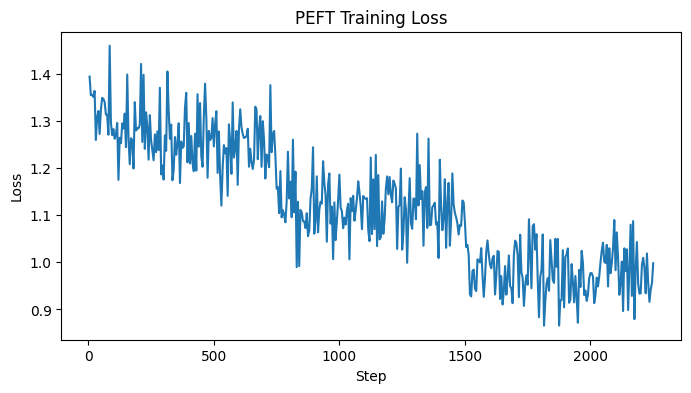

In [ ]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir=ADAPTER_DIR,
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    num_train_epochs=NUM_TRAIN_EPOCHS,
    learning_rate=LR,
    eval_strategy=EVAL_STRATEGY,
    logging_steps=5,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=eval_tokenized,
    data_collator=data_collator,

)

history = trainer.train()
trainer.save_model(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

# Plot training loss
import matplotlib.pyplot as plt
logs = trainer.state.log_history
steps, losses = [], []
for e in logs:
    if "loss" in e:
        steps.append(e.get("step", len(steps)))
        losses.append(e["loss"])
if steps and losses:
    plt.figure(figsize=(8, 4))
    plt.plot(steps, losses)
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title("PEFT Training Loss")
    plt.savefig(os.path.join(OUTPUT_DIR, "training_loss.png"), dpi=100, bbox_inches="tight")
    plt.show()

## CELL 10 — Evaluate PEFT Model

Same eval pipeline as baseline. Save to metrics_peft.json and append to metrics.csv.

In [ ]:
preds_peft, _, lat_peft, tok_peft = generate_summaries(peft_model, tokenizer, eval_data, do_sample=False, max_new_tokens=MAX_NEW_TOKENS)
rouge_peft = rouge.compute(predictions=preds_peft, references=refs_baseline)
_, _, bert_peft = bert_score(preds_peft, refs_baseline, lang="en", verbose=False)

metrics_peft = {
    "model": "peft",
    "rouge1": rouge_peft["rouge1"],
    "rouge2": rouge_peft["rouge2"],
    "rougel": rouge_peft["rougeL"],
    "bertscore_f1": float(bert_peft.mean().item()),
    "latency_sec_per_sample": float(np.mean(lat_peft)),
    "tokens_per_sec": float(np.sum(tok_peft) / max(1e-9, np.sum(lat_peft))),
}
with open(os.path.join(OUTPUT_DIR, "metrics_peft.json"), "w") as f:
    json.dump(metrics_peft, f, indent=2)

with open(csv_path, "a", newline="") as f:
    csv.DictWriter(f, fieldnames=["model", "rouge1", "rouge2", "rougel", "bertscore_f1", "latency_sec_per_sample", "tokens_per_sec"]).writerow(metrics_peft)

print("PEFT metrics:", metrics_peft)
max_display = 200
print("\n--- 5 samples ---")
for i in range(min(5, len(eval_data))):
    print(f"[{i+1}] Ref: {refs_baseline[i][:80]}")
    print(f"    Pred: {preds_peft[i][:80]}\n")

In [17]:
PRUNED_DIR = os.path.join(OUTPUT_DIR, "pruned_optimized")


#Pruning: fraction of weights zeroed (0.2 = 20% sparsity)
PRUNING_SPARSITY = 0.2
print(f"PRUNED_DIR = {PRUNED_DIR}, PRUNING_SPARSITY = {PRUNING_SPARSITY}")

PRUNED_DIR = ./output_summarization/pruned_optimized, PRUNING_SPARSITY = 0.2


## CELL 11 — Optimization: Magnitude Pruning

Apply unstructured magnitude pruning to the PEFT model (linear layers) to achieve target sparsity. No extra training; fast runtime.

Applying 20% magnitude pruning to 393 modules...


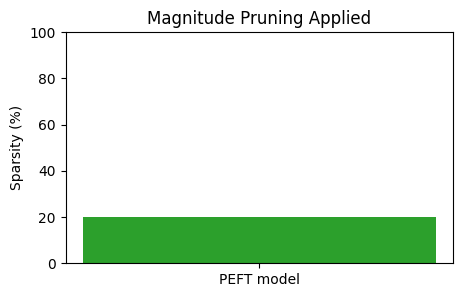

In [ ]:
# Pruning: unstructured magnitude pruning on PEFT model
import torch.nn.utils.prune as prune
import matplotlib.pyplot as plt

pruning_ok = False
try:
    # Collect parameters to prune: Linear with float weight, or LoRA A/B (for 4-bit models)
    to_prune = []
    for name, module in peft_model.named_modules():
        if isinstance(module, torch.nn.Linear) and hasattr(module, "weight") and module.weight is not None:
            try:
                if module.weight.dtype in (torch.float32, torch.float16, torch.bfloat16):
                    to_prune.append((module, "weight"))
            except Exception:
                pass
    # Fallback for 4-bit: prune LoRA adapter matrices
    if len(to_prune) == 0:
        for name, module in peft_model.named_modules():
            for attr in ("lora_A", "lora_B"):
                if hasattr(module, attr):
                    p = getattr(module, attr)
                    if p is not None and hasattr(p, "default") and p.default.dtype in (torch.float32, torch.float16, torch.bfloat16):
                        to_prune.append((module, attr))

    print(f"Applying {PRUNING_SPARSITY*100:.0f}% magnitude pruning to {len(to_prune)} modules...")
    prune.global_unstructured(
        to_prune,
        pruning_method=prune.L1Unstructured,
        amount=PRUNING_SPARSITY,
    )

    # Make pruning permanent (remove reparametrization)
    for module, name in to_prune:
        prune.remove(module, name)

    # Optional: save pruned model
    os.makedirs(PRUNED_DIR, exist_ok=True)
    peft_model.save_pretrained(PRUNED_DIR)
    tokenizer.save_pretrained(PRUNED_DIR)

    # Plot: sparsity applied (single bar for documentation)
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(["PEFT model"], [PRUNING_SPARSITY * 100], color="#2ca02c")
    ax.set_ylabel("Sparsity (%)")
    ax.set_title("Magnitude Pruning Applied")
    ax.set_ylim(0, 100)
    plt.savefig(os.path.join(OUTPUT_DIR, "pruning_sparsity.jpg"), dpi=100, bbox_inches="tight", format="jpg")
    plt.savefig(os.path.join(OUTPUT_DIR, "pruning_sparsity.png"), dpi=100, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    # Evaluate pruned model
    preds_opt, _, lat_opt, tok_opt = generate_summaries(peft_model, tokenizer, eval_data, do_sample=False, max_new_tokens=MAX_NEW_TOKENS)
    rouge_opt = rouge.compute(predictions=preds_opt, references=refs_baseline)
    _, _, bert_opt = bert_score(preds_opt, refs_baseline, lang="en", verbose=False)

    metrics_optimized = {
        "model": "optimized",
        "rouge1": rouge_opt["rouge1"],
        "rouge2": rouge_opt["rouge2"],
        "rougel": rouge_opt["rougeL"],
        "bertscore_f1": float(bert_opt.mean().item()),
        "latency_sec_per_sample": float(np.mean(lat_opt)),
        "tokens_per_sec": float(np.sum(tok_opt) / max(1e-9, np.sum(lat_opt))),
    }
    with open(os.path.join(OUTPUT_DIR, "metrics_optimized.json"), "w") as f:
        json.dump(metrics_optimized, f, indent=2)

    with open(csv_path, "a", newline="") as f:
        csv.DictWriter(f, fieldnames=["model", "rouge1", "rouge2", "rougel", "bertscore_f1", "latency_sec_per_sample", "tokens_per_sec"]).writerow(metrics_optimized)

    #print("Optimized (pruned) metrics:", metrics_optimized)
    pruning_ok = True
except Exception as ex:
    import traceback
    print(f"Pruning failed: {ex}")
    traceback.print_exc()
    print("Proceeding with baseline + PEFT comparison only.")

In [1]:
print("Optimized (pruned) metrics:", metrics_optimized)

Optimized (pruned) metrics: {'model': 'optimized', 'rouge1': 0.2224657397536744, 'rouge2': 0.07835295915693483, 'rougel': 0.1651847739462958, 'bertscore_f1': 0.868436572958632, 'latency_sec_per_sample': 8.673489255857268, 'tokens_per_sec': 12.785792967057276}


## CELL 12 — Final Comparison Tables + Plots

Load metrics.csv, display dataframe, create bar charts for ROUGE, BERTScore, latency, tokens/sec. Save plots.

In [ ]:
#!pip install numpy pandas matplotlib

Metrics comparison:


,model,rouge1,rouge2,rougel,bertscore_f1,latency_sec_per_sample,tokens_per_sec
0,baseline,0.211636,0.069443,0.163105,0.863272,9.785129,13.500437
1,peft,0.235567,0.086730,0.179748,0.872264,12.847489,9.546286
2,optimized,0.222466,0.078353,0.165185,0.868437,8.673489,12.785793


CSV tables saved.


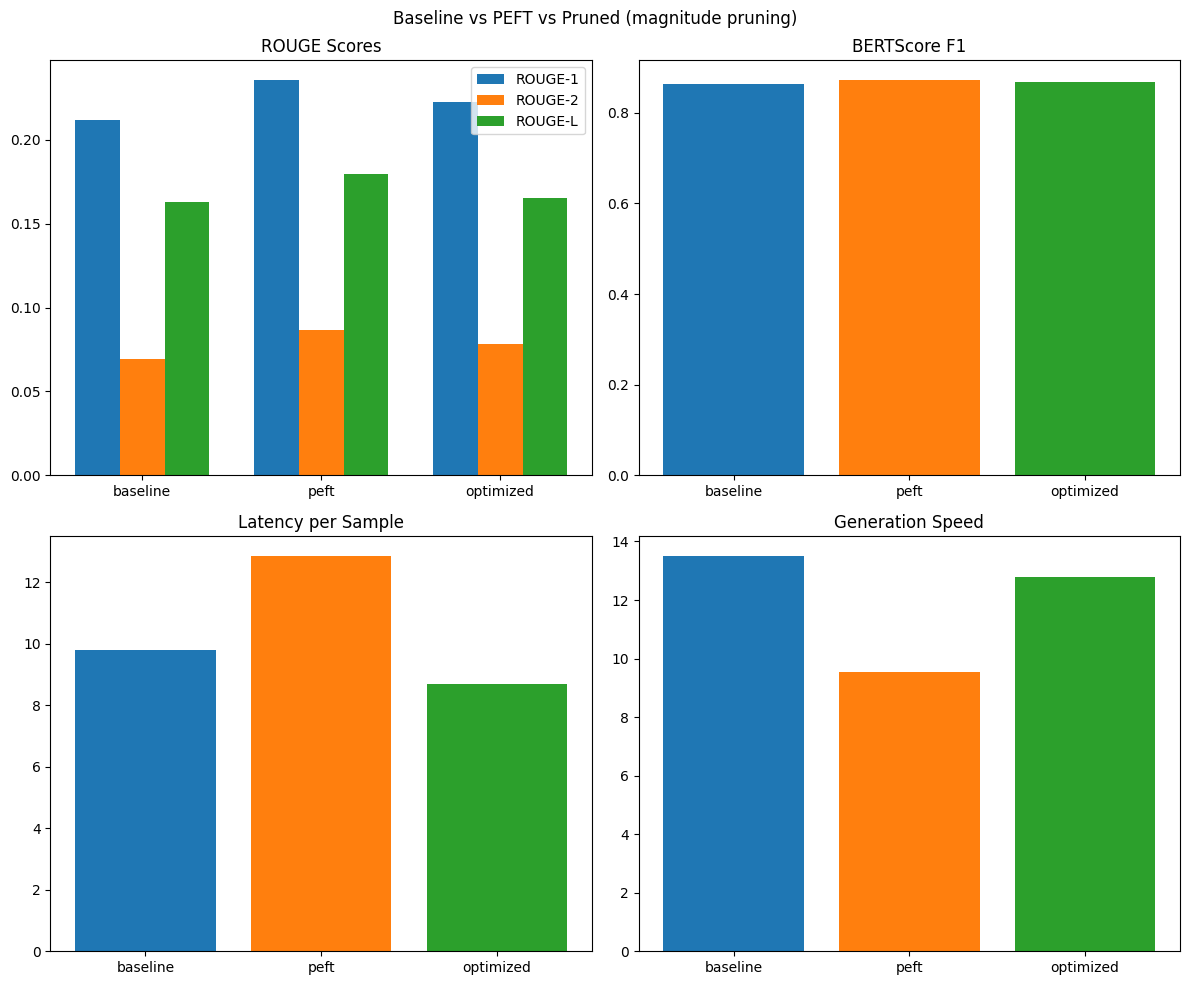


All comparison tables and plots saved under: ./eval_outputs
(Baseline, PEFT, Optimized)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(csv_path)
print("Metrics comparison:")
display(df)

# ----- Save ALL comparison tables to CSV -----
os.makedirs(OUTPUT_DIR, exist_ok=True)
comparison_table_csv = os.path.join(OUTPUT_DIR, "comparison_table.csv")
df.to_csv(comparison_table_csv, index=False)
print(f"Saved: {comparison_table_csv}")

rouge_csv = os.path.join(OUTPUT_DIR, "comparison_rouge.csv")
df[["model", "rouge1", "rouge2", "rougel"]].to_csv(rouge_csv, index=False)
print(f"Saved: {rouge_csv}")

bertscore_csv = os.path.join(OUTPUT_DIR, "comparison_bertscore.csv")
df[["model", "bertscore_f1"]].to_csv(bertscore_csv, index=False)
print(f"Saved: {bertscore_csv}")

latency_csv = os.path.join(OUTPUT_DIR, "comparison_latency.csv")
df[["model", "latency_sec_per_sample", "tokens_per_sec"]].to_csv(latency_csv, index=False)
print(f"Saved: {latency_csv}")

# ----- All plots use matplotlib; save each as JPG (and combined) -----
models = df["model"].tolist()
x = np.arange(len(models))
w = 0.25
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"][:len(models)]

def save_plot_jpg(fig, name):
    path = os.path.join(OUTPUT_DIR, name)
    fig.savefig(path, dpi=120, bbox_inches="tight", format="jpg")
    print(f"Saved: {path}")

# 1) ROUGE only
fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(x - w, df["rouge1"], w, label="ROUGE-1")
ax1.bar(x, df["rouge2"], w, label="ROUGE-2")
ax1.bar(x + w, df["rougel"], w, label="ROUGE-L")
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.set_ylabel("Score")
ax1.set_title("ROUGE Scores")
ax1.legend()
save_plot_jpg(fig1, "plot_rouge.jpg")
plt.close(fig1)

# 2) BERTScore only
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.bar(models, df["bertscore_f1"], color=colors)
ax2.set_ylabel("BERTScore F1")
ax2.set_title("BERTScore F1 Comparison")
save_plot_jpg(fig2, "plot_bertscore.jpg")
plt.close(fig2)

# 3) Latency only
fig3, ax3 = plt.subplots(figsize=(8, 5))
ax3.bar(models, df["latency_sec_per_sample"], color=colors)
ax3.set_ylabel("Latency (sec/sample)")
ax3.set_title("Latency per Sample")
save_plot_jpg(fig3, "plot_latency.jpg")
plt.close(fig3)

# 4) Tokens/sec only
fig4, ax4 = plt.subplots(figsize=(8, 5))
ax4.bar(models, df["tokens_per_sec"], color=colors)
ax4.set_ylabel("Tokens/sec")
ax4.set_title("Generation Speed")
save_plot_jpg(fig4, "plot_tokens_per_sec.jpg")
plt.close(fig4)

# 5) Combined 2x2: Baseline vs PEFT vs Pruned (display + save JPG and PNG)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Baseline vs PEFT vs Pruned (magnitude pruning)", fontsize=12, y=1.02)
ax1 = axes[0, 0]
ax1.bar(x - w, df["rouge1"], w, label="ROUGE-1")
ax1.bar(x, df["rouge2"], w, label="ROUGE-2")
ax1.bar(x + w, df["rougel"], w, label="ROUGE-L")
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.set_ylabel("Score")
ax1.set_title("ROUGE Scores")
ax1.legend()
ax2 = axes[0, 1]
ax2.bar(models, df["bertscore_f1"], color=colors)
ax2.set_ylabel("BERTScore F1")
ax2.set_title("BERTScore F1 Comparison")
ax3 = axes[1, 0]
ax3.bar(models, df["latency_sec_per_sample"], color=colors)
ax3.set_ylabel("Latency (sec/sample)")
ax3.set_title("Latency per Sample")
ax4 = axes[1, 1]
ax4.bar(models, df["tokens_per_sec"], color=colors)
ax4.set_ylabel("Tokens/sec")
ax4.set_title("Generation Speed")
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "comparison_plots.jpg"), dpi=120, bbox_inches="tight", format="jpg")
fig.savefig(os.path.join(OUTPUT_DIR, "comparison_plots.png"), dpi=120, bbox_inches="tight")
print(f"Saved: {os.path.join(OUTPUT_DIR, 'comparison_plots.jpg')}, comparison_plots.png")
plt.show()
plt.close(fig)

print(f"\nAll comparison tables (CSV) and plots (JPG) saved under: {OUTPUT_DIR}")
print("(Baseline, PEFT, Pruned)")

## CELL 13 — Results Summary

Concise textual summary of improvements and trade-offs.

In [2]:
import pandas as pd



df = pd.DataFrame(data)

# ---- Results Summary ----
print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)

rows = [
    df[df["model"] == m].iloc[0]
    for m in ["baseline", "peft", "optimized"]
    if m in df["model"].values
]

for i, r in enumerate(rows):
    name = ["BASELINE (pretrained)", "PEFT (LoRA/QLoRA)", "OPTIMIZED (pruned)"][i]
    print(f"\n{i+1}. {name}:")
    print(f"   ROUGE-1/L: {r['rouge1']:.3f} / {r['rougel']:.3f}, BERTScore F1: {r['bertscore_f1']:.3f}")
    print(f"   Latency: {r['latency_sec_per_sample']:.3f} sec/sample, Speed: {r['tokens_per_sec']:.1f} tok/s")

if len(rows) >= 2:
    r1_delta = (rows[1]['rouge1'] - rows[0]['rouge1']) * 100
    print(f"\n   PEFT vs Baseline ROUGE-1: {r1_delta:+.1f}%")

print("\nTRADE-OFFS:")
print("  - PEFT adds minimal params, typically improves quality on in-domain summarization.")
print("  - Pruning zeroes a fraction of weights (e.g. 20% sparsity); fast, no extra training.")
print("  - Pruning can reduce model size / inference cost; may slightly affect quality vs PEFT.")
print("=" * 60)

RESULTS SUMMARY

1. BASELINE (pretrained):
   ROUGE-1/L: 0.212 / 0.163, BERTScore F1: 0.863
   Latency: 9.785 sec/sample, Speed: 13.5 tok/s

2. PEFT (LoRA/QLoRA):
   ROUGE-1/L: 0.236 / 0.180, BERTScore F1: 0.872
   Latency: 12.847 sec/sample, Speed: 9.5 tok/s

3. OPTIMIZED (pruned):
   ROUGE-1/L: 0.222 / 0.165, BERTScore F1: 0.868
   Latency: 8.673 sec/sample, Speed: 12.8 tok/s

   PEFT vs Baseline ROUGE-1: +2.4%

TRADE-OFFS:
  - PEFT adds minimal params, typically improves quality on in-domain summarization.
  - Pruning zeroes a fraction of weights (e.g. 20% sparsity); fast, no extra training.
  - Pruning can reduce model size / inference cost; may slightly affect quality vs PEFT.
